Import required libraries

In [5]:
import numpy as np
import time
import pandas as pd
from sklearn.cross_decomposition import PLSRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.model_selection import KFold

Data loading and standardization

In [6]:
X_raw = np.loadtxt("dataF_final.csv", delimiter=",")
Y_raw = np.loadtxt("dataC_final.csv", delimiter=",")

if Y_raw.ndim == 1:
    Y_raw = Y_raw.reshape(-1, 1)

scaler_x = StandardScaler()
scaler_y = StandardScaler()

X = scaler_x.fit_transform(X_raw)
Y = scaler_y.fit_transform(Y_raw)

PLS Cross-Validation error

This function computes the cross-validated RMSE using Partial Least Squares (PLS).

In [7]:
def cv_rmse(X, y, n_comp):
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    rmses = []
    
    # Ensure n_components isn't larger than available features
    actual_comp = min(n_comp, X.shape[1])
    model = PLSRegression(n_components=actual_comp)

    for tr, te in kf.split(X):
        model.fit(X[tr], y[tr])
        pred = model.predict(X[te])
        rmses.append(np.sqrt(mean_squared_error(y[te], pred)))

    return np.mean(rmses)

Variable Importance in Projection (VIP)

VIP scores measure the contribution of each wavelength to the PLS model.

In [8]:
def compute_vip(pls, X):
    t, w, q = pls.x_scores_, pls.x_weights_, pls.y_loadings_
    p, h = w.shape
    s = np.diag(t.T @ t @ q.T @ q).reshape(h, -1)
    Wnorm2 = np.sum(w ** 2, axis=0)

    vip = np.zeros(p)
    for i in range(p):
        weight = np.sum([s[j] * (w[i,j]**2) / Wnorm2[j] for j in range(h)])
        vip[i] = np.sqrt(p * weight / np.sum(s))
        
    return vip

Adaptive Lasso coefficient estimation

Adaptive Lasso improves feature selection by assigning different penalties to each variable.
Here, Ridge regression is used to compute initial weights.

In [9]:
def adaptive_lasso_weights(X, y, alpha=0.001, gamma=0.2):
    
    init_model = Ridge(alpha=1)
    init_model.fit(X, y)
    
    weights = 1.0 / (np.abs(init_model.coef_).flatten() + 1e-10)**gamma
    
    X_w = X / weights
    model = Lasso(alpha=alpha, max_iter=20000)
    model.fit(X_w, y)
    
    return np.abs(model.coef_ / weights)

Adaptive Sparse Competitive Adaptive Reweighted Sampling

In [10]:
def adaptive_scars(X, Y, target_idx):
    y = Y[:, target_idx]
    n_features = X.shape[1]
    idx = np.arange(n_features)
    
    n_iter = 80
    min_vars = 5 
    a = n_features / min_vars
    k = np.log(a) / (n_iter - 1)
    
    best_subset = idx
    min_rmse = float('inf')
    
    for i in range(n_iter):
        Xs = X[:, idx]
        
        # PLS + VIP
        pls = PLSRegression(n_components=min(20, Xs.shape[1]))
        pls.fit(Xs, y)
        vips = compute_vip(pls, Xs)
        
        # Adaptive Lasso
        betas = adaptive_lasso_weights(Xs, y)
        importance = vips * betas + 1e-12
        
        # Validation
        current_rmse = cv_rmse(Xs, y, 20)
        if current_rmse < min_rmse:
            min_rmse = current_rmse
            best_subset = idx.copy()
            
        # Exponential feature reduction
        new_size = int(round(a * np.exp(-k * (i + 1)) * min_vars))
        if new_size < min_vars:
            break
        
        idx = idx[np.argsort(-importance)[:new_size]]
        
    return best_subset

Regression models and cross-validation

In [11]:
results_list = []
all_predictions = {}
kf = KFold(n_splits=5, shuffle=True, random_state=42)

test_models = {
    "PLSR": PLSRegression(n_components=20),
    "Ridge": Ridge(alpha=1),
    "Lasso": Lasso(alpha=0.001),
    "ElasticNet": ElasticNet(alpha=0.001, l1_ratio=0.001)
}

Adaptive Sparse CARS and Model evaluation

In [12]:
print(f"{'Target':<8} | {'Model':<12} | {'R2_test':<10} | {'RMSE_test':<10} | {'Features':<8}")
print("-" * 70)

for t in range(Y.shape[1]):
    print(f"\nOptimizing Target {t+1}...")
    start = time.time()

    best_features = adaptive_scars(X, Y, t)
    X_selected = X[:, best_features]
    y_target = Y[:, t]

    fold_scores = {name: {"r2": [], "rmse": []} for name in test_models.keys()}
    temp_true = {name: [] for name in test_models.keys()}
    temp_pred = {name: [] for name in test_models.keys()}
    for train_idx, test_idx in kf.split(X_selected):

        X_train, X_test = X_selected[train_idx], X_selected[test_idx]
        y_train, y_test = y_target[train_idx], y_target[test_idx]

        for name, model in test_models.items():
            model.fit(X_train, y_train)
            pred = model.predict(X_test).flatten()

            temp_true[name].extend(y_test)
            temp_pred[name].extend(pred)            
            
            r2 = r2_score(y_test, pred)
            rmse = np.sqrt(mean_squared_error(y_test, pred))

            fold_scores[name]["r2"].append(r2)
            fold_scores[name]["rmse"].append(rmse)

    for name in test_models.keys():
        mean_r2 = np.mean(fold_scores[name]["r2"])
        mean_rmse = np.mean(fold_scores[name]["rmse"])

        results_list.append({
            "Target": t+1,
            "Model": name,
            "R2_test": mean_r2,
            "RMSE_test": mean_rmse,
            "Features": len(best_features)
        })
        
        all_predictions[(t+1, name)] = (
        np.array(temp_true[name]),
        np.array(temp_pred[name])
    )
        print(f"T{t+1:<6} | {name:<12} | {mean_r2:.4f}   | {mean_rmse:.4f}   | {len(best_features):<8}")

    print(f"RunTime: {time.time() - start:.2f}s")


      

Target   | Model        | R2_test    | RMSE_test  | Features
----------------------------------------------------------------------

Optimizing Target 1...


c:\Users\HP\miniconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.204e-02, tolerance: 2.109e-02
  model = cd_fast.enet_coordinate_descent(
c:\Users\HP\miniconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.664e-01, tolerance: 2.219e-02
  model = cd_fast.enet_coordinate_descent(
c:\Users\HP\miniconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.237e-02, tolerance: 2.0

T1      | PLSR         | 0.9541   | 0.2076   | 157     
T1      | Ridge        | 0.9621   | 0.1912   | 157     
T1      | Lasso        | 0.9488   | 0.2216   | 157     
T1      | ElasticNet   | 0.9604   | 0.1954   | 157     
RunTime: 18.80s

Optimizing Target 2...
T2      | PLSR         | 0.9604   | 0.1975   | 157     
T2      | Ridge        | 0.9663   | 0.1825   | 157     
T2      | Lasso        | 0.9542   | 0.2119   | 157     
T2      | ElasticNet   | 0.9648   | 0.1860   | 157     
RunTime: 18.58s

Optimizing Target 3...


c:\Users\HP\miniconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.842e-02, tolerance: 1.596e-02
  model = cd_fast.enet_coordinate_descent(
c:\Users\HP\miniconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.380e-01, tolerance: 1.596e-02
  model = cd_fast.enet_coordinate_descent(
c:\Users\HP\miniconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.239e-01, tolerance: 2.3

T3      | PLSR         | 0.9685   | 0.1543   | 170     
T3      | Ridge        | 0.9729   | 0.1484   | 170     
T3      | Lasso        | 0.9534   | 0.1939   | 170     
T3      | ElasticNet   | 0.9663   | 0.1650   | 170     
RunTime: 19.57s

Optimizing Target 4...


c:\Users\HP\miniconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.711e-01, tolerance: 1.964e-02
  model = cd_fast.enet_coordinate_descent(
c:\Users\HP\miniconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.466e-01, tolerance: 1.872e-02
  model = cd_fast.enet_coordinate_descent(
c:\Users\HP\miniconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.396e-01, tolerance: 2.0

T4      | PLSR         | 0.9493   | 0.2168   | 157     
T4      | Ridge        | 0.9490   | 0.2169   | 157     
T4      | Lasso        | 0.9344   | 0.2477   | 157     
T4      | ElasticNet   | 0.9407   | 0.2313   | 157     
RunTime: 17.40s

Optimizing Target 5...


c:\Users\HP\miniconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.024e-01, tolerance: 2.275e-02
  model = cd_fast.enet_coordinate_descent(
c:\Users\HP\miniconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.756e-01, tolerance: 2.275e-02
  model = cd_fast.enet_coordinate_descent(
c:\Users\HP\miniconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.670e-01, tolerance: 1.3

T5      | PLSR         | 0.9102   | 0.2486   | 183     
T5      | Ridge        | 0.9297   | 0.2072   | 183     
T5      | Lasso        | 0.8531   | 0.3135   | 183     
T5      | ElasticNet   | 0.9214   | 0.2149   | 183     
RunTime: 23.30s


c:\Users\HP\miniconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.975e-01, tolerance: 2.061e-02
  model = cd_fast.enet_coordinate_descent(
c:\Users\HP\miniconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.019e-01, tolerance: 2.302e-02
  model = cd_fast.enet_coordinate_descent(
c:\Users\HP\miniconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.927e-01, tolerance: 2.3

Best Model Per Target (Adaptive Sparse CARS)

In [13]:
results_df = pd.DataFrame(results_list)

best_models = (
    results_df.sort_values("RMSE_test")
    .groupby("Target")
    .first()
    .reset_index()
)

best_models


,Target,Model,R2_test,RMSE_test,Features
0,1,Ridge,0.962085,0.191161,157
1,2,Ridge,0.966313,0.182475,157
2,3,Ridge,0.972950,0.148361,170
3,4,PLSR,0.949292,0.216845,157
4,5,Ridge,0.929675,0.207227,183


Predicted vs Observed for best model per target

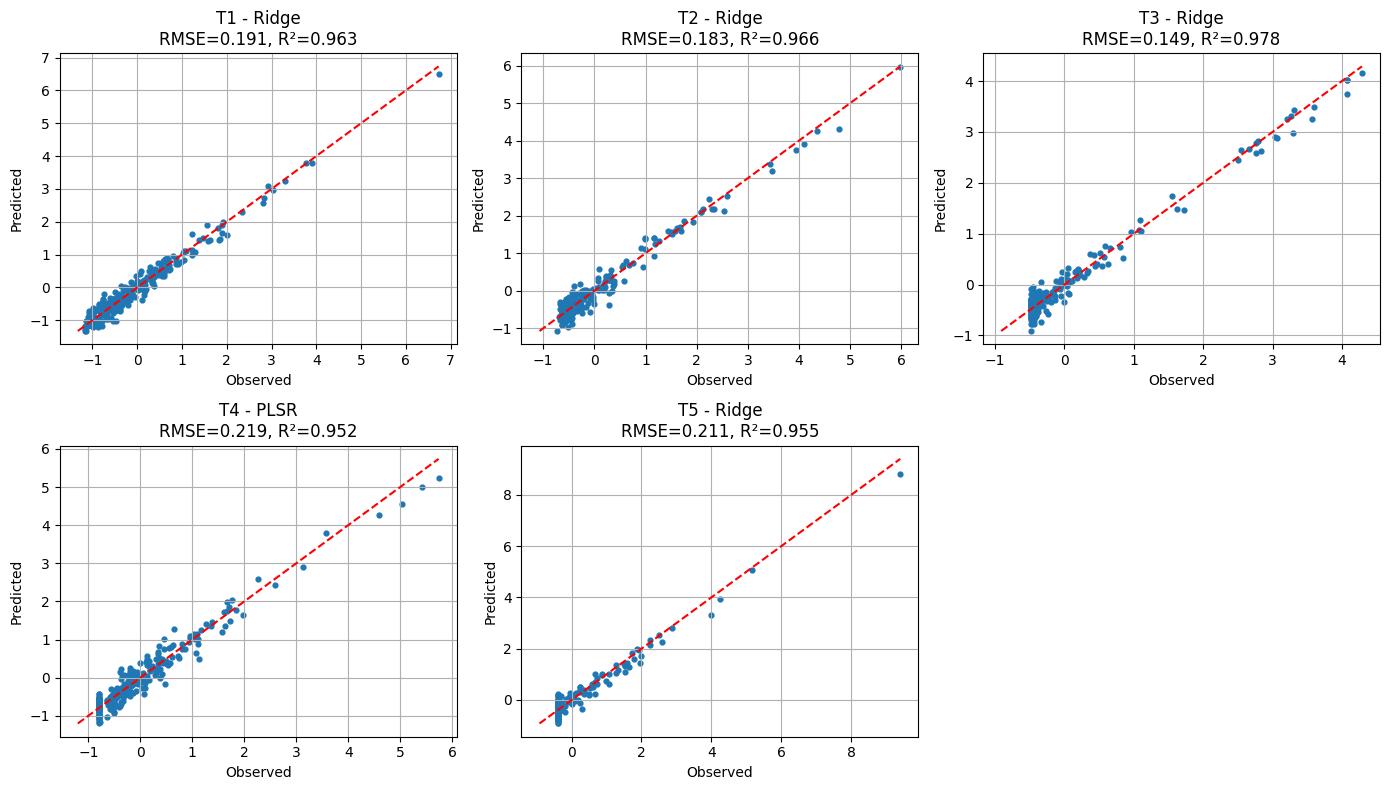

In [14]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score

def plot_best_models(best_models, all_predictions):
    
    cols = 3
    rows = int(np.ceil(len(best_models) / cols))

    plt.figure(figsize=(14, 4 * rows))

    for i, row in best_models.iterrows():
        t = row["Target"]
        model = row["Model"]

        y_true, y_pred = all_predictions[(t, model)]

        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        r2 = r2_score(y_true, y_pred)

        plt.subplot(rows, cols, i + 1)
        plt.scatter(y_true, y_pred, s=12)

        min_v = min(y_true.min(), y_pred.min())
        max_v = max(y_true.max(), y_pred.max())
        plt.plot([min_v, max_v], [min_v, max_v], "r--")

        plt.title(f"T{t} - {model}\nRMSE={rmse:.3f}, R²={r2:.3f}")
        plt.xlabel("Observed")
        plt.ylabel("Predicted")
        plt.grid()

    plt.tight_layout()
    plt.show()
    
plot_best_models(best_models, all_predictions)